Exploratory Data Analysis

In [2]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast
import seaborn as sns

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [3]:
df_DA_CH = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'Switzerland')].copy()

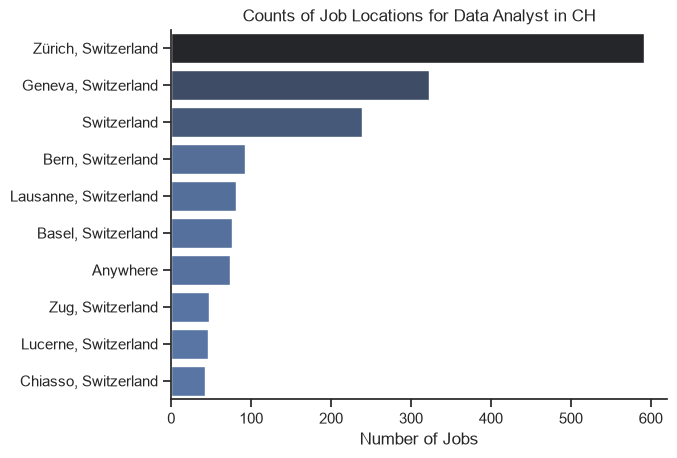

In [16]:
df_plot = df_DA_CH['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style="ticks")
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Counts of Job Locations for Data Analyst in CH')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

In [24]:
df_DA_CH['job_health_insurance'].value_counts()

job_health_insurance
False    2343
Name: count, dtype: int64

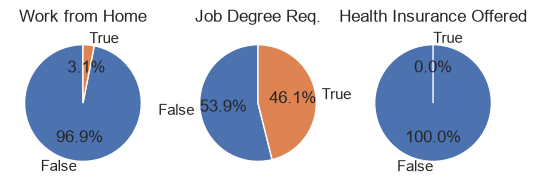

In [27]:
fig, ax = plt.subplots(1, 3)

dict_column = {
    'job_work_from_home': 'Work from Home',
    'job_no_degree_mention': 'Job Degree Req.',
    'job_health_insurance': 'Health Insurance Offered',
}

for i, (column, title) in enumerate(dict_column.items()):
    counts = df_DA_CH[column].value_counts().reindex([False, True], fill_value=0)
    ax[i].pie(counts, startangle=90, autopct='%1.1f%%', labels=['False', 'True'])
    ax[i].set_title(title)

plt.show()

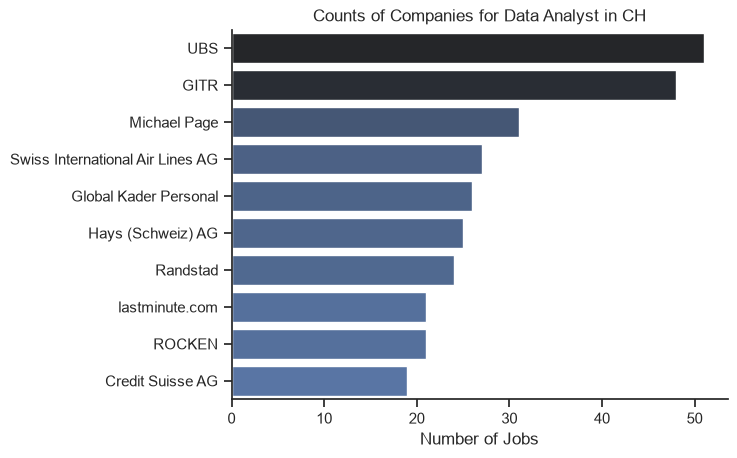

In [28]:
df_plot = df_DA_CH['company_name'].value_counts().head(10).to_frame()

sns.set_theme(style="ticks")
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Counts of Companies for Data Analyst in CH')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()